In [ ]:
pip install requests pandas

In [ ]:
# ==========================================================
# PROJECT : Sentiment Analysis of Online Shopping News
# PART 1 : Data Collection Using NewsAPI
# ==========================================================

# Import Libraries
import requests
import pandas as pd

# ==========================================================
# NEWS API KEY
# ==========================================================

API_KEY = "fbc5bf0af1714c1bb9838d145f641c22"

# ==========================================================
# SEARCH QUERY
# ==========================================================

query = "Amazon OR Flipkart OR Online Shopping"

# ==========================================================
# NEWS API URL
# ==========================================================

url = "https://newsapi.org/v2/everything"

# ==========================================================
# PARAMETERS
# ==========================================================

parameters = {

    "q": query,

    "language": "en",

    "sortBy": "publishedAt",

    "pageSize": 100,

    "apiKey": API_KEY

}

# ==========================================================
# REQUEST DATA FROM API
# ==========================================================

response = requests.get(url, params=parameters)

news = response.json()

# ==========================================================
# CHECK API STATUS
# ==========================================================

print("Status :", news["status"])

print("Total Results :", news["totalResults"])

# ==========================================================
# CREATE EMPTY LIST
# ==========================================================

dataset = []

# ==========================================================
# STORE NEWS DATA
# ==========================================================

for article in news["articles"]:

    dataset.append({

        "Source": article["source"]["name"],

        "Author": article["author"],

        "Title": article["title"],

        "Description": article["description"],

        "Content": article["content"],

        "Published_Date": article["publishedAt"],

        "URL": article["url"]

    })

# ==========================================================
# CREATE DATAFRAME
# ==========================================================

df = pd.DataFrame(dataset)

# ==========================================================
# DISPLAY DATA
# ==========================================================

print(df.head())

print(df.shape)

print(df.columns)

# ==========================================================
# CHECK NULL VALUES
# ==========================================================

print("\nMissing Values\n")

print(df.isnull().sum())

# ==========================================================
# REMOVE NULL VALUES
# ==========================================================

df.dropna(inplace=True)

# ==========================================================
# REMOVE DUPLICATE RECORDS
# ==========================================================

df.drop_duplicates(inplace=True)

print("\nShape After Cleaning")

print(df.shape)

# ==========================================================
# SAVE DATASET
# ==========================================================

df.to_csv(

    "Online_Shopping_News.csv",

    index=False,

    encoding="utf-8"

)

print("\nDataset Saved Successfully")

# ==========================================================
# FIRST FIVE RECORDS
# ==========================================================

print(df.head())

Status : ok
Total Results : 7958
          Source                      Author  \
0            BGR  staff@bgr.com (Zak Wojnar)   
1      PetaPixel              Chris Niccolls   
2   Dealnews.com                        None   
3  The Gadgeteer                   Rei Padla   
4   Fly4free.com                    Giovanni   

                                               Title  \
0  10 Home Theater Mistakes You Might Be Making, ...   
1  Which High-Resolution Full-Frame Camera Has th...   
2  Pen+Gear 7.5" x 9.7" Ruled Composition Book: 3...   
3  Kershaw Bel Air XL Gives the Lightweight EDC F...   
4  HIGH SEASON   Stylish 5* hotel in Da Nang, Vie...   

                                         Description  \
0  Setting up your dream home theater can be a co...   
1  The mid-range sensor market is very competitiv...   
2  This Pen+Gear composition book is down to just...   
3  Kershaw didn’t make the Bel Air line easier to...   
4  Planning a trip to Vietnam? We've got a great ...   

    

In [ ]:
# ==========================================================
# PART 2 : DATA PREPROCESSING
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ==========================================================
# DOWNLOAD NLTK PACKAGES
# ==========================================================

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab') # Added to resolve LookupError

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("Online_Shopping_News.csv")

print(df.head())

print(df.shape)

# ==========================================================
# COMBINE TEXT COLUMNS
# ==========================================================

df["News"] = (
    df["Title"].fillna("") + " " +
    df["Description"].fillna("") + " " +
    df["Content"].fillna("")
)

# ==========================================================
# SELECT REQUIRED COLUMN
# ==========================================================

df = df[["News"]]

print(df.head())

# ==========================================================
# REMOVE NULL VALUES
# ==========================================================

df.dropna(inplace=True)

# ==========================================================
# REMOVE DUPLICATES
# ==========================================================

df.drop_duplicates(inplace=True)

# ==========================================================
# CONVERT TO LOWERCASE
# ==========================================================

df["News"] = df["News"].str.lower()

# ==========================================================
# REMOVE URLS
# ==========================================================

def remove_urls(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)

df["News"] = df["News"].apply(remove_urls)

# ==========================================================
# REMOVE EMAILS
# ==========================================================

def remove_email(text):
    return re.sub(r'\S+@\S+', '', text)

df["News"] = df["News"].apply(remove_email)

# ==========================================================
# REMOVE NUMBERS
# ==========================================================

def remove_numbers(text):
    return re.sub(r'\d+', '', text)

df["News"] = df["News"].apply(remove_numbers)

# ==========================================================
# REMOVE PUNCTUATION
# ==========================================================

def remove_punctuation(text):
    return text.translate(
        str.maketrans('', '', string.punctuation)
    )

df["News"] = df["News"].apply(remove_punctuation)

# ==========================================================
# REMOVE EXTRA SPACES
# ==========================================================

df["News"] = df["News"].str.replace(
    r'\s+',
    ' ',
    regex=True
)

df["News"] = df["News"].str.strip()

# ==========================================================
# TOKENIZATION
# ==========================================================

df["Tokens"] = df["News"].apply(word_tokenize)

# ==========================================================
# REMOVE STOPWORDS
# ==========================================================

stop_words = set(stopwords.words("english"))

df["Tokens"] = df["Tokens"].apply(

    lambda words: [

        word

        for word in words

        if word not in stop_words

    ]

)

# ==========================================================
# LEMMATIZATION
# ==========================================================

lemmatizer = WordNetLemmatizer()

df["Tokens"] = df["Tokens"].apply(

    lambda words: [

        lemmatizer.lemmatize(word)

        for word in words

    ]

)

# ==========================================================
# JOIN TOKENS
# ==========================================================

df["Clean_Text"] = df["Tokens"].apply(

    lambda words: " ".join(words)

)

# ==========================================================
# REMOVE EMPTY ROWS
# ==========================================================

df = df[df["Clean_Text"].str.strip() != ""]

# ==========================================================
# DISPLAY CLEAN DATA
# ==========================================================

print(df.head())

print(df.shape)

# ==========================================================
# SAVE PREPROCESSED DATA
# ==========================================================

df.to_csv(

    "Preprocessed_Online_Shopping_News.csv",

    index=False,

    encoding="utf-8"

)

print("Preprocessed Dataset Saved Successfully")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


          Source                      Author  \
0            BGR  staff@bgr.com (Zak Wojnar)   
1      PetaPixel              Chris Niccolls   
2  The Gadgeteer                   Rei Padla   
3   Fly4free.com                    Giovanni   
4      SB Nation              Antonio Losada   

                                               Title  \
0  10 Home Theater Mistakes You Might Be Making, ...   
1  Which High-Resolution Full-Frame Camera Has th...   
2  Kershaw Bel Air XL Gives the Lightweight EDC F...   
3  HIGH SEASON   Stylish 5* hotel in Da Nang, Vie...   
4  Newcastle Fans Face Harsh Reality After Sandro...   

                                         Description  \
0  Setting up your dream home theater can be a co...   
1  The mid-range sensor market is very competitiv...   
2  Kershaw didn’t make the Bel Air line easier to...   
3  Planning a trip to Vietnam? We've got a great ...   
4  Newcastle United’s summer is not unfolding lik...   

                                     

In [ ]:
pip install textblob gensim

In [ ]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
# ==========================================================
# PART 3 : FEATURE EXTRACTION
# ==========================================================

import pandas as pd

from textblob import TextBlob

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from gensim.models import Word2Vec

# ==========================================================
# LOAD PREPROCESSED DATA
# ==========================================================

df = pd.read_csv("Preprocessed_Online_Shopping_News.csv")

print(df.head())

# ==========================================================
# SENTIMENT LABELING USING TEXTBLOB
# ==========================================================

def sentiment_label(text):

    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:

        return "Positive"

    elif polarity < 0:

        return "Negative"

    else:

        return "Neutral"

df["Sentiment"] = df["Clean_Text"].apply(sentiment_label)

print(df["Sentiment"].value_counts())

# ==========================================================
# BAG OF WORDS
# ==========================================================

bow = CountVectorizer(max_features=5000)

X_bow = bow.fit_transform(df["Clean_Text"])

print("Bag of Words Shape :", X_bow.shape)

# ==========================================================
# TF-IDF
# ==========================================================

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df["Clean_Text"])

print("TF-IDF Shape :", X_tfidf.shape)

# ==========================================================
# WORD2VEC
# ==========================================================

sentences = df["Clean_Text"].apply(lambda x: x.split()).tolist()

word2vec_model = Word2Vec(

    sentences=sentences,

    vector_size=100,

    window=5,

    min_count=1,

    workers=4

)

print("Word2Vec Model Created Successfully")

# Example Word Vector

print(word2vec_model.wv["amazon"])

# ==========================================================
# FEATURES
# ==========================================================

X = X_tfidf

y = df["Sentiment"]

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

# ==========================================================
# SAVE LABELLED DATASET
# ==========================================================

df.to_csv(

    "Labelled_Online_Shopping_News.csv",

    index=False,

    encoding="utf-8"

)

print("Labelled Dataset Saved Successfully")

                                                News  \
0  home theater mistakes you might be making acco...   
1  which highresolution fullframe camera has the ...   
2  kershaw bel air xl gives the lightweight edc f...   
3  high season stylish hotel in da nang vietnam f...   
4  newcastle fans face harsh reality after sandro...   

                                              Tokens  \
0  ['home', 'theater', 'mistake', 'might', 'makin...   
1  ['highresolution', 'fullframe', 'camera', 'bes...   
2  ['kershaw', 'bel', 'air', 'xl', 'give', 'light...   
3  ['high', 'season', 'stylish', 'hotel', 'da', '...   
4  ['newcastle', 'fan', 'face', 'harsh', 'reality...   

                                          Clean_Text  
0  home theater mistake might making according en...  
1  highresolution fullframe camera best sensor mi...  
2  kershaw bel air xl give lightweight edc favori...  
3  high season stylish hotel da nang vietnam €dou...  
4  newcastle fan face harsh reality sandro tonali..

In [ ]:
# ==========================================================
# PART 4 : MACHINE LEARNING MODELS
# ==========================================================

import pandas as pd
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

# ==========================================================
# LOGISTIC REGRESSION
# ==========================================================

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

lr_prediction = lr_model.predict(X_test)

lr_accuracy = accuracy_score(
    y_test,
    lr_prediction
)

print("Logistic Regression Accuracy :", lr_accuracy)

# ==========================================================
# NAIVE BAYES
# ==========================================================

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_prediction = nb_model.predict(X_test)

nb_accuracy = accuracy_score(
    y_test,
    nb_prediction
)

print("Naive Bayes Accuracy :", nb_accuracy)

# ==========================================================
# SUPPORT VECTOR MACHINE
# ==========================================================

svm_model = SVC(
    kernel="linear",
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

svm_prediction = svm_model.predict(X_test)

svm_accuracy = accuracy_score(
    y_test,
    svm_prediction
)

print("SVM Accuracy :", svm_accuracy)

# ==========================================================
# DECISION TREE
# ==========================================================

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_prediction = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_prediction
)

print("Decision Tree Accuracy :", dt_accuracy)

# ==========================================================
# RANDOM FOREST
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

print("Random Forest Accuracy :", rf_accuracy)

# ==========================================================
# MODEL COMPARISON
# ==========================================================

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "SVM",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        lr_accuracy,
        nb_accuracy,
        svm_accuracy,
        dt_accuracy,
        rf_accuracy
    ]

})

comparison["Accuracy"] = comparison["Accuracy"] * 100

print("\nModel Comparison\n")

print(comparison)

# ==========================================================
# BEST MODEL
# ==========================================================

best_model_name = comparison.loc[
    comparison["Accuracy"].idxmax(),
    "Model"
]

print("\nBest Model :", best_model_name)

# ==========================================================
# SELECT BEST MODEL
# ==========================================================

models = {

    "Logistic Regression": lr_model,

    "Naive Bayes": nb_model,

    "SVM": svm_model,

    "Decision Tree": dt_model,

    "Random Forest": rf_model

}

best_model = models[best_model_name]

# ==========================================================
# SAVE BEST MODEL
# ==========================================================

joblib.dump(
    best_model,
    "Best_Sentiment_Model.pkl"
)

joblib.dump(
    tfidf,
    "TFIDF_Vectorizer.pkl"
)

print("\nBest Model Saved Successfully")

# ==========================================================
# SAMPLE PREDICTION
# ==========================================================

sample_news = [

    "Amazon launches a new online shopping feature with faster delivery."

]

sample_vector = tfidf.transform(sample_news)

prediction = best_model.predict(sample_vector)

print("\nSample News")

print(sample_news[0])

print("\nPredicted Sentiment")

print(prediction[0])

Logistic Regression Accuracy : 0.6111111111111112
Naive Bayes Accuracy : 0.6111111111111112
SVM Accuracy : 0.6111111111111112
Decision Tree Accuracy : 0.7777777777777778
Random Forest Accuracy : 0.6666666666666666

Model Comparison

                 Model   Accuracy
0  Logistic Regression  61.111111
1          Naive Bayes  61.111111
2                  SVM  61.111111
3        Decision Tree  77.777778
4        Random Forest  66.666667

Best Model : Decision Tree

Best Model Saved Successfully

Sample News
Amazon launches a new online shopping feature with faster delivery.

Predicted Sentiment
Positive


Accuracy : 0.7777777777777778
Precision : 0.837037037037037
Recall : 0.7777777777777778
F1 Score : 0.7393162393162394

Classification Report

              precision    recall  f1-score   support

    Negative       1.00      0.33      0.50         6
     Neutral       1.00      1.00      1.00         1
    Positive       0.73      1.00      0.85        11

    accuracy                           0.78        18
   macro avg       0.91      0.78      0.78        18
weighted avg       0.84      0.78      0.74        18


Confusion Matrix

[[ 2  0  4]
 [ 0  1  0]
 [ 0  0 11]]


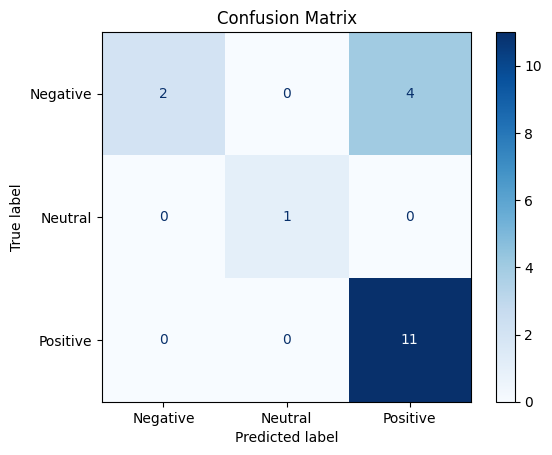

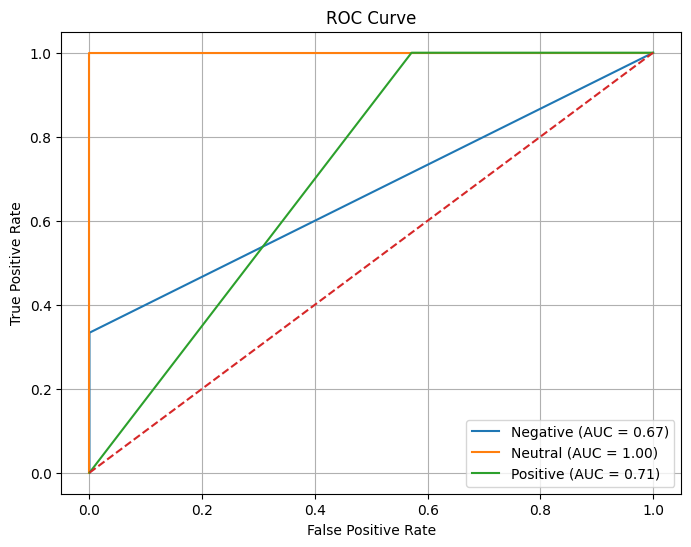


Evaluation Results Saved Successfully

========== FINAL RESULTS ==========

      Metric     Value
0   Accuracy  0.777778
1  Precision  0.837037
2     Recall  0.777778
3   F1 Score  0.739316


In [ ]:
# ==========================================================
# PART 5 : MODEL EVALUATION
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

# ==========================================================
# LOAD SAVED MODEL
# ==========================================================

import joblib

model = joblib.load("Best_Sentiment_Model.pkl")

# ==========================================================
# PREDICTION
# ==========================================================

y_pred = model.predict(X_test)

# ==========================================================
# ACCURACY
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

# ==========================================================
# PRECISION
# ==========================================================

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision :", precision)

# ==========================================================
# RECALL
# ==========================================================

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Recall :", recall)

# ==========================================================
# F1 SCORE
# ==========================================================

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("F1 Score :", f1)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix\n")

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# ==========================================================
# ROC CURVE
# ==========================================================

classes = model.classes_

y_test_binary = label_binarize(
    y_test,
    classes=classes
)

y_score = model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(len(classes)):

    fpr, tpr, threshold = roc_curve(
        y_test_binary[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{classes[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================================
# SAVE METRICS
# ==========================================================

evaluation = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1
    ]

})

evaluation.to_csv(
    "Model_Evaluation.csv",
    index=False
)

print("\nEvaluation Results Saved Successfully")

# ==========================================================
# DISPLAY RESULTS
# ==========================================================

print("\n========== FINAL RESULTS ==========\n")

print(evaluation)

                                                News  \
0  home theater mistakes you might be making acco...   
1  which highresolution fullframe camera has the ...   
2  kershaw bel air xl gives the lightweight edc f...   
3  high season stylish hotel in da nang vietnam f...   
4  newcastle fans face harsh reality after sandro...   

                                              Tokens  \
0  ['home', 'theater', 'mistake', 'might', 'makin...   
1  ['highresolution', 'fullframe', 'camera', 'bes...   
2  ['kershaw', 'bel', 'air', 'xl', 'give', 'light...   
3  ['high', 'season', 'stylish', 'hotel', 'da', '...   
4  ['newcastle', 'fan', 'face', 'harsh', 'reality...   

                                          Clean_Text Sentiment  
0  home theater mistake might making according en...  Negative  
1  highresolution fullframe camera best sensor mi...  Positive  
2  kershaw bel air xl give lightweight edc favori...  Positive  
3  high season stylish hotel da nang vietnam €dou...  Positive  
4

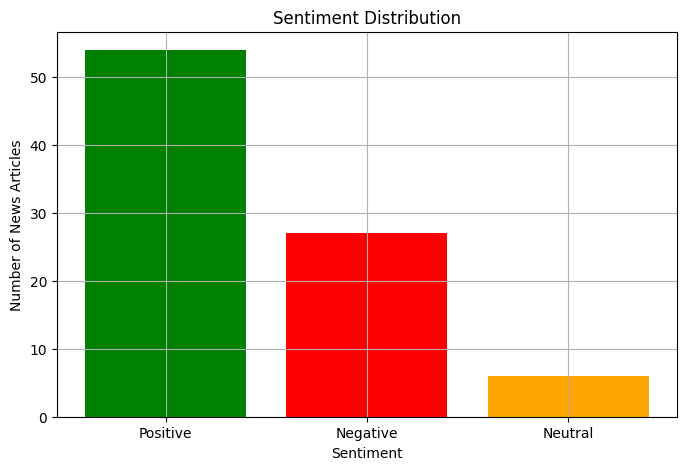

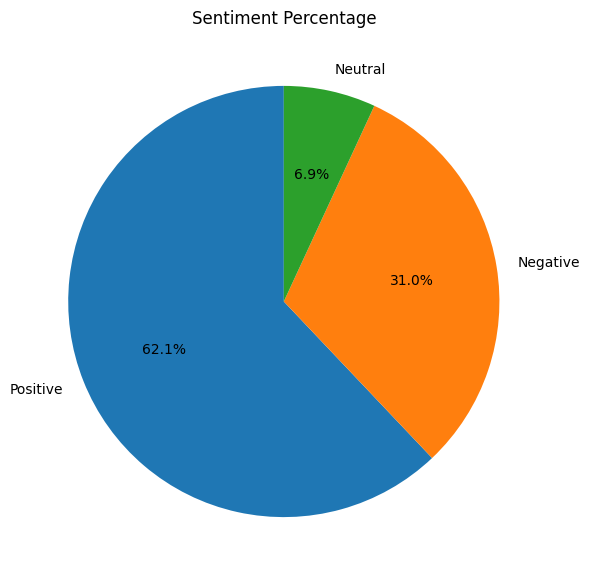

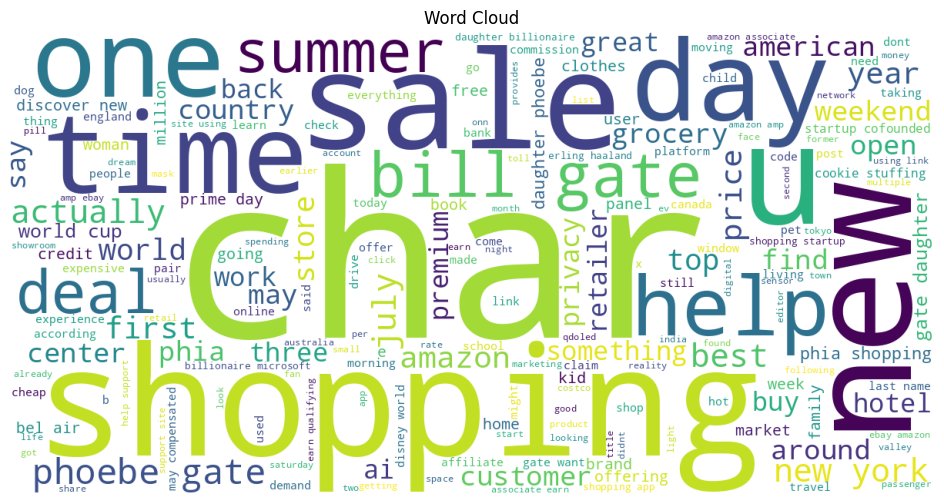

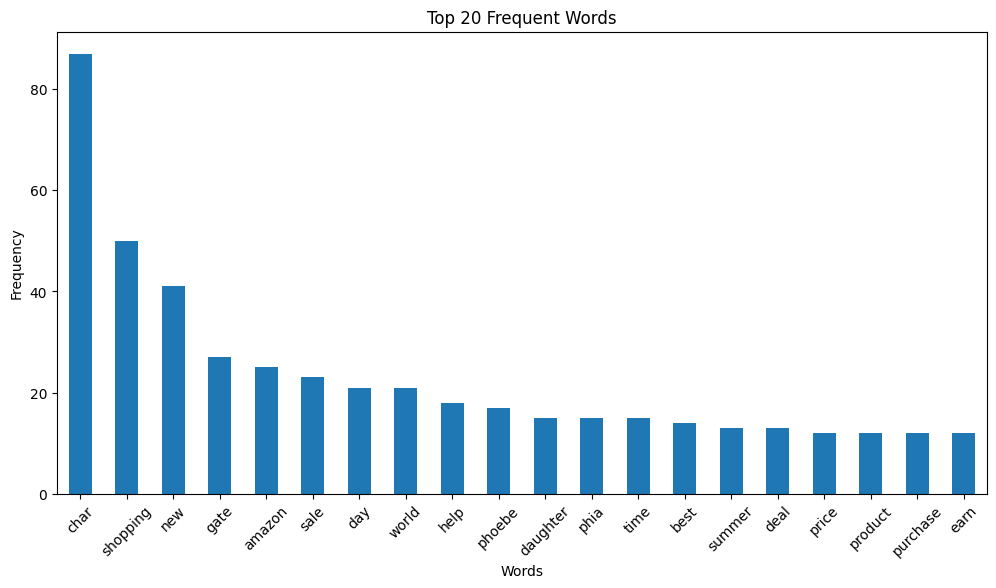

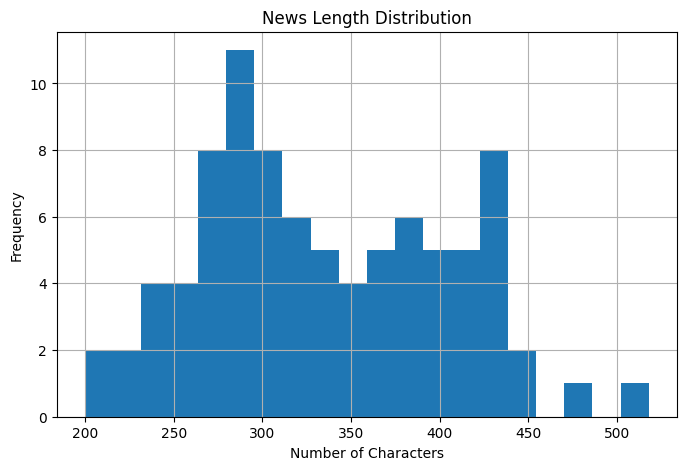

  Sentiment  Count
0  Positive     54
1  Negative     27
2   Neutral      6
Summary Saved Successfully

Positive News

1    highresolution fullframe camera best sensor mi...
2    kershaw bel air xl give lightweight edc favori...
3    high season stylish hotel da nang vietnam €dou...
4    newcastle fan face harsh reality sandro tonali...
5    adidas unidays adidas look increased previous ...
Name: Clean_Text, dtype: object

Negative News

0     home theater mistake might making according en...
12    former cast member reveals disney world night ...
14    hdmi cable equal expensive one usually waste s...
19    spent month living different country coming ba...
21    pangolinfoalexa python sdk pangolinfo amazon a...
Name: Clean_Text, dtype: object

Neutral News

18    ‘ chip shoulder ’ phoebe gate want million ai ...
29    ‘ chip shoulder ’ phoebe gate want million ai ...
59    james packer pack pda portofino getting engage...
64    phia accused ‘ cookie stuffing ’ taking affili...
65    p

In [ ]:
# ==========================================================
# PART 6 : DATA VISUALIZATION
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

# ==========================================================
# LOAD LABELLED DATASET
# ==========================================================

df = pd.read_csv("Labelled_Online_Shopping_News.csv")

print(df.head())

# ==========================================================
# SENTIMENT DISTRIBUTION
# ==========================================================

sentiment = df["Sentiment"].value_counts()

print(sentiment)

# ==========================================================
# BAR CHART
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    sentiment.index,
    sentiment.values,
    color=["green","red","orange"]
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of News Articles")

plt.grid(True)

plt.show()

# ==========================================================
# PIE CHART
# ==========================================================

plt.figure(figsize=(7,7))

plt.pie(
    sentiment.values,
    labels=sentiment.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sentiment Percentage")

plt.show()

# ==========================================================
# WORD CLOUD
# ==========================================================

text = " ".join(df["Clean_Text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud")

plt.show()

# ==========================================================
# TOP 20 FREQUENT WORDS
# ==========================================================

vectorizer = CountVectorizer(
    stop_words="english"
)

X = vectorizer.fit_transform(df["Clean_Text"])

word_frequency = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

top_words = word_frequency.sum().sort_values(
    ascending=False
).head(20)

plt.figure(figsize=(12,6))

top_words.plot(kind="bar")

plt.title("Top 20 Frequent Words")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# NEWS LENGTH DISTRIBUTION
# ==========================================================

df["News_Length"] = df["Clean_Text"].apply(len)

plt.figure(figsize=(8,5))

plt.hist(
    df["News_Length"],
    bins=20
)

plt.title("News Length Distribution")

plt.xlabel("Number of Characters")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

# ==========================================================
# SENTIMENT COUNT TABLE
# ==========================================================

summary = pd.DataFrame({

    "Sentiment":sentiment.index,

    "Count":sentiment.values

})

print(summary)

# ==========================================================
# SAVE SUMMARY
# ==========================================================

summary.to_csv(
    "Sentiment_Summary.csv",
    index=False
)

print("Summary Saved Successfully")

# ==========================================================
# DISPLAY SAMPLE NEWS
# ==========================================================

print("\nPositive News\n")

print(
    df[df["Sentiment"]=="Positive"][
        "Clean_Text"
    ].head(5)
)

print("\nNegative News\n")

print(
    df[df["Sentiment"]=="Negative"][
        "Clean_Text"
    ].head(5)
)

print("\nNeutral News\n")

print(
    df[df["Sentiment"]=="Neutral"][
        "Clean_Text"
    ].head(5)
)

print("\nVisualization Completed Successfully")

In [ ]:
# ==========================================================
# PART 7 : FINAL PREDICTION
# ==========================================================

import joblib
import pandas as pd

# ==========================================================
# LOAD MODEL
# ==========================================================

model = joblib.load("Best_Sentiment_Model.pkl")

vectorizer = joblib.load("TFIDF_Vectorizer.pkl")

print("Model Loaded Successfully")

# ==========================================================
# PREDICT SINGLE NEWS
# ==========================================================

news = input("Enter Online Shopping News : ")

news_vector = vectorizer.transform([news])

prediction = model.predict(news_vector)

print("\nPredicted Sentiment")

print(prediction[0])

# ==========================================================
# PREDICT MULTIPLE NEWS
# ==========================================================

sample_news = [

    "Amazon launches a new AI shopping assistant.",

    "Customers complain about delayed product delivery.",

    "Flipkart announces biggest festive sale."

]

sample_vector = vectorizer.transform(sample_news)

sample_prediction = model.predict(sample_vector)

result = pd.DataFrame({

    "News":sample_news,

    "Predicted Sentiment":sample_prediction

})

print(result)

# ==========================================================
# SAVE PREDICTION RESULTS
# ==========================================================

result.to_csv(

    "Prediction_Result.csv",

    index=False

)

print("\nPrediction Results Saved Successfully")

# ==========================================================
# LOAD LABELLED DATASET
# ==========================================================

df = pd.read_csv("Labelled_Online_Shopping_News.csv")

# ==========================================================
# PREDICT ENTIRE DATASET
# ==========================================================

prediction = model.predict(

    vectorizer.transform(df["Clean_Text"])

)

df["Predicted_Sentiment"] = prediction

# ==========================================================
# SAVE FINAL DATASET
# ==========================================================

df.to_csv(

    "Final_Predicted_Dataset.csv",

    index=False

)

print("\nFinal Dataset Saved Successfully")

# ==========================================================
# DISPLAY FINAL OUTPUT
# ==========================================================

print(df.head(10))

print("\nProject Completed Successfully")

Model Loaded Successfully
Enter Online Shopping News : good

Predicted Sentiment
Positive
                                                News Predicted Sentiment
0       Amazon launches a new AI shopping assistant.            Positive
1  Customers complain about delayed product deliv...            Positive
2           Flipkart announces biggest festive sale.            Positive

Prediction Results Saved Successfully

Final Dataset Saved Successfully
                                                News  \
0  home theater mistakes you might be making acco...   
1  which highresolution fullframe camera has the ...   
2  kershaw bel air xl gives the lightweight edc f...   
3  high season stylish hotel in da nang vietnam f...   
4  newcastle fans face harsh reality after sandro...   
5  off adidas with unidays adidas looks increased...   
6  we knew it was time to leave australia when we...   
7  apy unlimited cash back and free atm withdrawa...   
8  pet store marketing ideas ways to attr